# 02 Explicit Recommendations

In this notebook we will be exploring a few of the models to understand the recommender functionality as well as a visual on the quality of recommendations presented.

## Imports and Installs

In [1]:
# Reult visualiztion
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotnine as pn
from scipy.stats import ttest_rel

#Model Evaluation
import lenskit
from lenskit.data import load_movielens, Dataset, ItemListCollection
from lenskit.metrics import RBP, NDCG, MeasurementCollector, RMSE, RecipRank, Hit

#### Importing The necessary Datasets

In [2]:
test_item_data = ItemListCollection.load_parquet('/Users/ryanpeters7/Desktop/Spring 2026/DSCI 641/final project/data/cleaned_data/split_data/test_item_data.parquet')
print("Test Item Data has successfully been loaded!")

recipes = pd.read_csv('../data/raw_data/recipes.csv')
print('Recipes Dataset has been loaded for future reference!')
recipes.head()

Test Item Data has successfully been loaded!
Recipes Dataset has been loaded for future reference!


,RecipeId,Name,AuthorId,AuthorName,CookTime,PrepTime,TotalTime,DatePublished,Description,Images,...,SaturatedFatContent,CholesterolContent,SodiumContent,CarbohydrateContent,FiberContent,SugarContent,ProteinContent,RecipeServings,RecipeYield,RecipeInstructions
0,38,Low-Fat Berry Blue Frozen Dessert,1533,Dancer,PT24H,PT45M,PT24H45M,1999-08-09T21:46:00Z,Make and share this Low-Fat Berry Blue Frozen ...,"c(""https://img.sndimg.com/food/image/upload/w_...",...,1.3,8.0,29.8,37.1,3.6,30.2,3.2,4.0,NaN,"c(""Toss 2 cups berries with sugar."", ""Let stan..."
1,39,Biryani,1567,elly9812,PT25M,PT4H,PT4H25M,1999-08-29T13:12:00Z,Make and share this Biryani recipe from Food.com.,"c(""https://img.sndimg.com/food/image/upload/w_...",...,16.6,372.8,368.4,84.4,9.0,20.4,63.4,6.0,NaN,"c(""Soak saffron in warm milk for 5 minutes and..."
2,40,Best Lemonade,1566,Stephen Little,PT5M,PT30M,PT35M,1999-09-05T19:52:00Z,This is from one of my first Good House Keepi...,"c(""https://img.sndimg.com/food/image/upload/w_...",...,0.0,0.0,1.8,81.5,0.4,77.2,0.3,4.0,NaN,"c(""Into a 1 quart Jar with tight fitting lid, ..."
3,41,Carina's Tofu-Vegetable Kebabs,1586,Cyclopz,PT20M,PT24H,PT24H20M,1999-09-03T14:54:00Z,This dish is best prepared a day in advance to...,"c(""https://img.sndimg.com/food/image/upload/w_...",...,3.8,0.0,1558.6,64.2,17.3,32.1,29.3,2.0,4 kebabs,"c(""Drain the tofu, carefully squeezing out exc..."
4,42,Cabbage Soup,1538,Duckie067,PT30M,PT20M,PT50M,1999-09-19T06:19:00Z,Make and share this Cabbage Soup recipe from F...,"""https://img.sndimg.com/food/image/upload/w_55...",...,0.1,0.0,959.3,25.1,4.8,17.7,4.3,4.0,NaN,"c(""Mix everything together and bring to a boil..."


In [3]:
# Importing the recommendation data
print("Loading the recomendations...")

bias_recs = ItemListCollection.load_parquet('/Users/ryanpeters7/Desktop/Spring 2026/DSCI 641/final project/data/recs/bias_recs.parquet')
print("BIAS Recommendations Loaded!")

item_item_recs = ItemListCollection.load_parquet('/Users/ryanpeters7/Desktop/Spring 2026/DSCI 641/final project/data/recs/item_item_recs.parquet') 
print("ITEM-ITEM Recommendations Loaded!")

popular_recs = ItemListCollection.load_parquet('/Users/ryanpeters7/Desktop/Spring 2026/DSCI 641/final project/data/recs/popular_recs.parquet') 
print("POPULAR Recommendations Loaded!")

user_user_recs = ItemListCollection.load_parquet('/Users/ryanpeters7/Desktop/Spring 2026/DSCI 641/final project/data/recs/user_user_recs.parquet') 
print("USER-USER Recommendations Loaded!")

item_item_implicit_recs = ItemListCollection.load_parquet('/Users/ryanpeters7/Desktop/Spring 2026/DSCI 641/final project/data/recs/item_item_implicit_recs.parquet') 
print("ITEM_ITEM_IMPLICIT Recommendations Loaded!")

explicit_mf_recs = ItemListCollection.load_parquet('/Users/ryanpeters7/Desktop/Spring 2026/DSCI 641/final project/data/recs/explicit_mf_recs.parquet') 
print("EXPLICIT_MF Recommendations Loaded!")

implicit_mf_recs = ItemListCollection.load_parquet('/Users/ryanpeters7/Desktop/Spring 2026/DSCI 641/final project/data/recs/implicit_mf_recs.parquet') 
print("IMPLICIT_MF Recommendations Loaded!")

slim_recs = ItemListCollection.load_parquet('/Users/ryanpeters7/Desktop/Spring 2026/DSCI 641/final project/data/recs/slim_recs.parquet') 
print("SLIM Recommendations Loaded!")

lift_recs = ItemListCollection.load_parquet('/Users/ryanpeters7/Desktop/Spring 2026/DSCI 641/final project/data/recs/lift_recs.parquet') 
print("LIFT Recommendations Loaded!")

Loading the recomendations...
BIAS Recommendations Loaded!
ITEM-ITEM Recommendations Loaded!
POPULAR Recommendations Loaded!
USER-USER Recommendations Loaded!
ITEM_ITEM_IMPLICIT Recommendations Loaded!
EXPLICIT_MF Recommendations Loaded!
IMPLICIT_MF Recommendations Loaded!
SLIM Recommendations Loaded!
LIFT Recommendations Loaded!


In [4]:
# Importing prediciton data

print('Loading Prediciton Data...')
bias_preds = ItemListCollection.load_parquet('/Users/ryanpeters7/Desktop/Spring 2026/DSCI 641/final project/data/preds/bias_preds.parquet')
print('BIAS Predicitions Loaded!')
item_item_preds = ItemListCollection.load_parquet('/Users/ryanpeters7/Desktop/Spring 2026/DSCI 641/final project/data/preds/item_item_preds.parquet')
print('ITEM-ITEM Predictions Loaded!')
user_user_preds = ItemListCollection.load_parquet('/Users/ryanpeters7/Desktop/Spring 2026/DSCI 641/final project/data/preds/user_user_preds.parquet')
print('USER-USER Predictions Loaded!')
explicit_mf_preds = ItemListCollection.load_parquet('/Users/ryanpeters7/Desktop/Spring 2026/DSCI 641/final project/data/preds/explicit_mf_preds.parquet')
print('EXPLICIT-MF Predictions Loaded!')

Loading Prediciton Data...
BIAS Predicitions Loaded!
ITEM-ITEM Predictions Loaded!
USER-USER Predictions Loaded!
EXPLICIT-MF Predictions Loaded!


## Measuring Quality of Recommendations (Offline Metircs)

In [14]:
mc = MeasurementCollector()
mc.add_metric(NDCG(n=20))
mc.add_metric(RBP(n=20))
mc.add_metric(RecipRank(n=20))
mc.add_metric(Hit(n=5))

In [15]:
pop_results = mc.measure_run(popular_recs, test_item_data)

bias_results = mc.measure_run(popular_recs, test_item_data)

item_item_results = mc.measure_run(item_item_recs, test_item_data)

user_user_results = mc.measure_run(user_user_recs, test_item_data)

item_item_implicit_results = mc.measure_run(item_item_implicit_recs, test_item_data)

explicit_mf_results = mc.measure_run(explicit_mf_recs, test_item_data)

implicit_mf_results = mc.measure_run(implicit_mf_recs, test_item_data)

slim_results = mc.measure_run(slim_recs, test_item_data)

lift_results = mc.measure_run(lift_recs, test_item_data)

In [16]:
all_list_metrics = pd.concat({
    'pop': pop_results.list_metrics,
    'bias': bias_results.list_metrics,
    'item_item': item_item_results.list_metrics,
    'user_user': user_user_results.list_metrics,
    'item_item_implicit': item_item_implicit_results.list_metrics,
    'explicit_mf': explicit_mf_results.list_metrics,
    'implicit_mf': implicit_mf_results.list_metrics,
    'slim': slim_results.list_metrics,
    'lift': lift_results.list_metrics
}, names=['model'])
all_list_metrics

NDCG@20  RBP@20  RecipRank@20  Hit@5
model user_id                                      
pop   320216       0.0     0.0           0.0      0
      205690       0.0     0.0           0.0      0
      293007       0.0     0.0           0.0      0
      1390917      0.0     0.0           0.0      0
      790070       0.0     0.0           0.0      0
...                ...     ...           ...    ...
lift  57562        0.0     0.0           0.0      0
      1235365      0.0     0.0           0.0      0
      392230       0.0     0.0           0.0      0
      143086       0.0     0.0           0.0      0
      310900       0.0     0.0           0.0      0

[249147 rows x 4 columns]

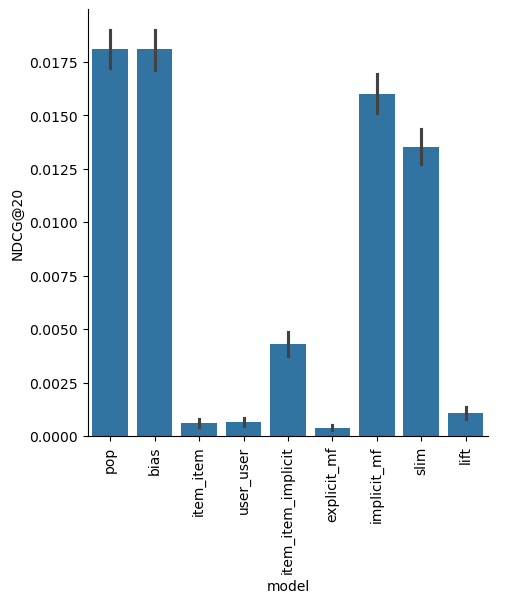

In [17]:
sns.catplot(all_list_metrics.reset_index(), x='model', y='NDCG@20', kind='bar')
plt.xticks(rotation=90)
plt.show()

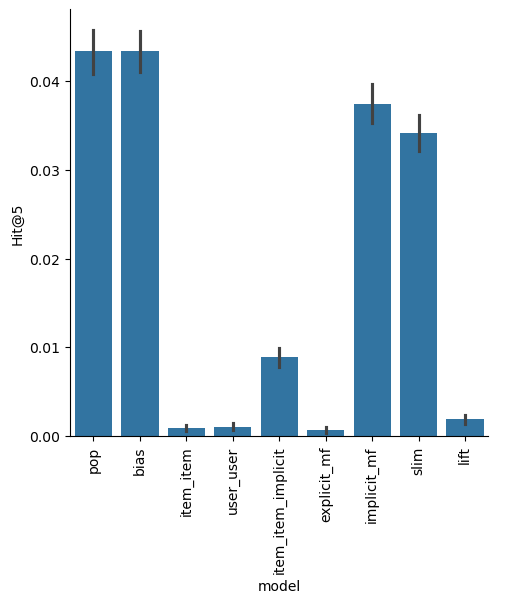

In [19]:
sns.catplot(all_list_metrics.reset_index(), x='model', y='Hit@5', kind='bar')
plt.xticks(rotation=90)
plt.show()

According to this plot of the NDCG for 20 item predicitons we see 4 models outperforming the others. These models are:
- PopScorer
- BiasScorer
- ImplicitMFScorer
- SlimScorer

Interestingly enough the performance of both Popular Scorer and BiasScorer seem to be the best, but I believe further investigation is needed to determine the quality of these recommendations.

## Evaluating the Predictions (Offline Metrics)

In [9]:
pmc = MeasurementCollector()
pmc.add_metric(RMSE(missing_truth='ignore'))

In [10]:
bias_preds_results = pmc.measure_run(bias_preds, test_item_data)
item_item_preds_results = pmc.measure_run(item_item_preds, test_item_data)
user_user_preds_results = pmc.measure_run(user_user_preds, test_item_data)
explicit_mf_preds_results = pmc.measure_run(explicit_mf_preds, test_item_data)

In [11]:
all_pred_metrics = pd.concat({
    'bias': bias_preds_results.list_metrics,
    'item_item': item_item_preds_results.list_metrics,
    'user_user': user_user_preds_results.list_metrics,
    'explicit_mf': explicit_mf_preds_results.list_metrics,
}, names=['model'])

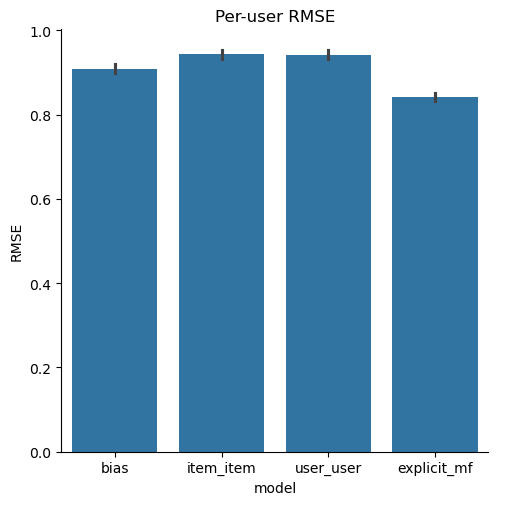

In [12]:
sns.catplot(all_pred_metrics.reset_index(), x='model', y='RMSE', kind='bar')
plt.title("Per-user RMSE")
plt.show()

## Testing the Predicitons

In this section I will be testing the predictions to see if they make any sense

In [20]:
import pickle
from lenskit import recommend

In [21]:
pop_path = '/Users/ryanpeters7/Desktop/Spring 2026/DSCI 641/final project/models/popular_pipeline.pkl'
with open(pop_path, 'rb') as f:
    pop_pipe = pickle.load(f)

In [ ]:
user_id = 1634 #Byriani
pop_recs = recommend(pop_pipe, user_id, n=20)
pop_recs_df = pop_recs.to_df()
pop_recs_df

,item_id,item_num,score,rank
0,45809,30611,1.000000,1
1,27208,17309,0.998269,2
2,89204,60712,0.997221,3
3,39087,25833,0.996235,4
4,32204,20965,0.995358,5
5,69173,47320,0.994496,6
6,22782,14053,0.993772,7
7,54257,36633,0.993062,8
8,25690,16183,0.992358,9
9,35813,23473,0.991672,10


In [24]:
filtered_recipes = recipes[['RecipeId', 'Name']]

In [27]:
pop_recs_merged = pd.merge(pop_recs_df, filtered_recipes, left_on='item_id', right_on='RecipeId', how='left')
pop_recs_merged

,item_id,item_num,score,rank,RecipeId,Name
0,45809,30611,1.000000,1,45809,Bourbon Chicken
1,27208,17309,0.998269,2,27208,To Die for Crock Pot Roast
2,89204,60712,0.997221,3,89204,Crock-Pot Chicken With Black Beans &amp; Cream...
3,39087,25833,0.996235,4,39087,Creamy Cajun Chicken Pasta
4,32204,20965,0.995358,5,32204,&quot;Whatever Floats Your Boat&quot; Brownies!
5,69173,47320,0.994496,6,69173,Kittencal's Italian Melt-In-Your-Mouth Meatballs
6,22782,14053,0.993772,7,22782,Jo Mama's World Famous Spaghetti
7,54257,36633,0.993062,8,54257,"Yes, Virginia There is a Great Meatloaf"
8,25690,16183,0.992358,9,25690,Pancakes
9,35813,23473,0.991672,10,35813,Oatmeal Raisin Cookies


#### Bias Scorer Recommendations

In [28]:
bias_path = '/Users/ryanpeters7/Desktop/Spring 2026/DSCI 641/final project/models/bias_pipeline.pkl'
with open(bias_path, 'rb') as f:
    bias_pipe = pickle.load(f)

In [29]:
user_id = 1634 #Byriani
bias_recs = recommend(bias_pipe, user_id, n=20)
bias_recs_df = bias_recs.to_df()
bias_recs_df

,item_id,item_num,score,rank
0,123,59,4.636584,1
1,128,63,4.636584,2
2,122,58,4.636584,3
3,114,52,4.636584,4
4,124,60,4.636584,5
5,126,61,4.636584,6
6,117,54,4.636584,7
7,120,57,4.636584,8
8,93,40,4.636584,9
9,91,38,4.636584,10


In [30]:
bias_recs_merged = pd.merge(bias_recs_df, filtered_recipes, left_on='item_id', right_on='RecipeId', how='left')
bias_recs_merged

,item_id,item_num,score,rank,RecipeId,Name
0,123,59,4.636584,1,123,Carrot Maple Cheesecake
1,128,63,4.636584,2,128,Caramel Apple Milkshakes
2,122,58,4.636584,3,122,Commissary Carrot Cake
3,114,52,4.636584,4,114,Chicken Breasts Saltimbocca
4,124,60,4.636584,5,124,Catherine's Excellent Yorkshire Pudding
5,126,61,4.636584,6,126,Carnation Lean Fettuccine Alfredo
6,117,54,4.636584,7,117,Blueberry Cookies
7,120,57,4.636584,8,120,Carrot Cake II
8,93,40,4.636584,9,93,Blue Stuffed Mushrooms
9,91,38,4.636584,10,91,Brown Rice and Vegetable Pilaf


In [31]:
ratings = pd.read_csv('/Users/ryanpeters7/Desktop/Spring 2026/DSCI 641/final project/data/raw_data/reviews.csv')
ratings.head()

,ReviewId,RecipeId,AuthorId,AuthorName,Rating,Review,DateSubmitted,DateModified
0,2,992,2008,gayg msft,5,better than any you can get at a restaurant!,2000-01-25T21:44:00Z,2000-01-25T21:44:00Z
1,7,4384,1634,Bill Hilbrich,4,"I cut back on the mayo, and made up the differ...",2001-10-17T16:49:59Z,2001-10-17T16:49:59Z
2,9,4523,2046,Gay Gilmore ckpt,2,i think i did something wrong because i could ...,2000-02-25T09:00:00Z,2000-02-25T09:00:00Z
3,13,7435,1773,Malarkey Test,5,easily the best i have ever had. juicy flavor...,2000-03-13T21:15:00Z,2000-03-13T21:15:00Z
4,14,44,2085,Tony Small,5,An excellent dish.,2000-03-28T12:51:00Z,2000-03-28T12:51:00Z


In [32]:
user_1634_data = ratings[ratings['AuthorId'] == 1634]
user_1634_data.head()

,ReviewId,RecipeId,AuthorId,AuthorName,Rating,Review,DateSubmitted,DateModified
1,7,4384,1634,Bill Hilbrich,4,"I cut back on the mayo, and made up the differ...",2001-10-17T16:49:59Z,2001-10-17T16:49:59Z
869,1376,8909,1634,Bill Hilbrich,3,Using the basic concept of this recipe as a st...,2001-07-02T16:36:10Z,2001-07-02T16:36:10Z
902,1425,8729,1634,Bill Hilbrich,2,I realize that the object is to keep this simp...,2001-07-05T10:36:15Z,2001-07-05T10:36:15Z
906,1430,9115,1634,Bill Hilbrich,5,A sweet/sour dressing with a little punch ... ...,2001-07-05T10:36:15Z,2001-07-05T10:36:15Z
1078,1784,5174,1634,Bill Hilbrich,0,"This recipe comes from Marsha Adams, who hoste...",2001-07-25T10:28:08Z,2001-07-25T10:28:08Z


In [39]:
filtered_recipes_2 = recipes[['RecipeId', 'Name', 'RecipeCategory']]

In [40]:
user_1634_data_merged = pd.merge(user_1634_data, filtered_recipes_2, left_on='RecipeId', right_on='RecipeId', how='left')
user_1634_data_merged.head(10)

,ReviewId,RecipeId,AuthorId,AuthorName,Rating,Review,DateSubmitted,DateModified,Name,RecipeCategory
0,7,4384,1634,Bill Hilbrich,4,"I cut back on the mayo, and made up the differ...",2001-10-17T16:49:59Z,2001-10-17T16:49:59Z,Curry Dip,Weeknight
1,1376,8909,1634,Bill Hilbrich,3,Using the basic concept of this recipe as a st...,2001-07-02T16:36:10Z,2001-07-02T16:36:10Z,Mushrooms la Grecque,Lunch/Snacks
2,1425,8729,1634,Bill Hilbrich,2,I realize that the object is to keep this simp...,2001-07-05T10:36:15Z,2001-07-05T10:36:15Z,Super Simple Stroganoff,< 60 Mins
3,1430,9115,1634,Bill Hilbrich,5,A sweet/sour dressing with a little punch ... ...,2001-07-05T10:36:15Z,2001-07-05T10:36:15Z,Mustard Pepper Dressing,Salad Dressings
4,1784,5174,1634,Bill Hilbrich,0,"This recipe comes from Marsha Adams, who hoste...",2001-07-25T10:28:08Z,2001-07-25T10:28:08Z,Amish Dip,Tuna
5,2350,10783,1634,Bill Hilbrich,0,"Before I try this recipe, it would be helpful ...",2001-08-15T11:58:19Z,2001-08-15T11:58:19Z,Chicken with Lemon,Lunch/Snacks
6,3534,11530,1634,Bill Hilbrich,4,"Just to sweeten this up a bit, I mixed the yel...",2001-09-14T21:39:51Z,2001-09-14T21:39:51Z,Easy Mustard Chicken,Lunch/Snacks
7,3584,11641,1634,Bill Hilbrich,4,"A very easy, but nice way to make dumblings, t...",2001-09-16T17:42:12Z,2001-09-16T17:42:12Z,Dumplings for Soup,German
8,3605,11674,1634,Bill Hilbrich,5,"Great recipe ... just as a suggestion, I would...",2001-09-16T17:42:12Z,2001-09-16T17:42:12Z,Angel Hair Pasta With Chicken,Chicken Breast
9,3609,9982,1634,Bill Hilbrich,4,"To make this soup just a little richer, I woul...",2001-09-16T17:42:12Z,2001-09-16T17:42:12Z,Canadian Cheddar Cheese Soup,One Dish Meal


In [41]:
user_1634_data_merged = user_1634_data_merged.sort_values(by= 'Rating', ascending=False)

In [42]:
user_1634_data_merged.head(20)

,ReviewId,RecipeId,AuthorId,AuthorName,Rating,Review,DateSubmitted,DateModified,Name,RecipeCategory
78,1199003,291770,1634,Bill Hilbrich,5,I was looking for something different instead ...,2011-03-09T16:55:04Z,2011-03-09T16:55:04Z,Mustard Curry Sauce,Sauces
28,6458,16193,1634,Bill Hilbrich,5,"After it was folded over, I was treated to a d...",2001-12-27T16:27:09Z,2001-12-27T16:27:09Z,Easy Omelet for One,One Dish Meal
56,91424,84458,1634,Bill Hilbrich,5,"I was served this dish not long ago, and when ...",2004-03-02T20:55:47Z,2004-03-02T20:55:47Z,Liz's Pesto Lasagna,< 60 Mins
23,4336,10082,1634,Bill Hilbrich,5,This is a very quick and easy recipe that can ...,2001-11-05T12:17:18Z,2001-11-05T12:17:18Z,Quick Alfredo Sauce,Sauces
55,80695,44435,1634,Bill Hilbrich,5,"Although this recipe is fairly simple, it did ...",2003-12-24T18:04:42Z,2003-12-24T18:04:42Z,Roast Beef Salad,Low Protein
54,62966,68581,1634,Bill Hilbrich,5,This is a very colorful side dish that complem...,2003-08-09T17:57:12Z,2003-08-09T17:57:12Z,Green Beans With Mushrooms,Vegetable
53,47853,41497,1634,Bill Hilbrich,5,Without a doubt this qualifies as a Hornorary ...,2003-04-05T18:57:17Z,2003-04-05T18:57:17Z,Chicken Delight,Weeknight
51,42633,27823,1634,Bill Hilbrich,5,"Very easy to make, light, but crunchy and very...",2003-02-24T22:38:00Z,2003-02-24T22:38:00Z,Almond Poppy Seed Shortbread,Dessert
50,35776,46531,1634,Bill Hilbrich,5,I will definitely try this recipe again. If yo...,2002-12-27T20:13:19Z,2002-12-27T20:13:19Z,Easy Tuna Pasta Salad,One Dish Meal
63,141993,104248,1634,Bill Hilbrich,5,BRAVO !! This recipe really made my day. I hav...,2004-12-25T13:35:49Z,2004-12-25T13:35:49Z,Microwave Poached Egg on Toast,Breakfast


In [43]:
user_1634_data_merged['RecipeCategory'].value_counts()

RecipeCategory
Lunch/Snacks       15
One Dish Meal      11
Vegetable           6
Sauces              4
Breakfast           4
Chicken             4
Low Protein         3
< 15 Mins           3
Meat                3
Chicken Breast      2
Drop Cookies        2
German              2
Pork                2
Beverages           2
Spreads             2
Weeknight           2
< 60 Mins           2
Spaghetti           1
Salad Dressings     1
Dessert             1
Poultry             1
Very Low Carbs      1
White Rice          1
Cheese              1
Tuna                1
Jellies             1
Whole Turkey        1
Name: count, dtype: int64

In [34]:
len(user_1634_data_merged)

79